#### Integrantes:

Jhonatan Caro

Andres Londoño

Victor Galeano

# Introducción a MLOps (Notebook 01)

En este notebook vas a recorrer un flujo completo (y reproducible) de *machine learning* para **clasificación binaria** usando *scikit-learn*:

- Generación de datos sintéticos (con valores faltantes para simular “datos reales”).
- EDA mínimo para entender tipos de variables y calidad del dataset.
- Feature engineering sencillo.
- Split de train/test.
- **Pipeline** de preprocesamiento + modelo (evita *data leakage*).
- Evaluación con métricas: *accuracy*, *precision*, *recall*, *F1*, ROC-AUC, matriz de confusión y efectos del **umbral** (*threshold*).

Objetivo: no “ganar” el mejor score (los datos son sintéticos), sino practicar buenas prácticas y entender qué significa la salida del modelo.
__________________________________

## ¿Qué es *data leakage*? (explicación fácil)

**Data leakage** (fuga de información) pasa cuando el modelo “hace trampa” sin querer, porque en entrenamiento ve información que **no debería ver**.

Piensa en esto:

- En `train` el modelo *aprende*.
- En `test` el modelo debe comportarse como si fueran **datos nuevos**.

Hay *leakage* si (por accidente) usas datos del `test` para preparar el `train`.

### Ejemplo muy común
Si calculas la **mediana** para imputar valores faltantes usando *todo el dataset* (train + test), entonces el modelo está usando información del test.

### ¿Por qué el `Pipeline` ayuda?
Porque el flujo correcto es:

1. Separar `train/test`
2. Hacer `pipeline.fit(X_train, y_train)` → aquí el pipeline aprende (medianas, escalado, one-hot) **solo con train**
3. Hacer `pipeline.predict(X_test)` → aquí solo aplica las mismas reglas al test

Resultado: la evaluación es más realista (más parecida a producción).

Ejemplo:
Supongamos un dataset con una feature a la cual le hacen falta valores en algunos registros.

- Calculas la mediana solo con X_train.
- Rellenas X_train con esa mediana.
- Rellenas X_test con esa misma mediana (la del train).

In [68]:
%load_ext autoreload
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from generate_data import UserGenerator

In [70]:
generator_data = UserGenerator(seed=42, n_samples=10000)
df = generator_data.create_dataset()

df.head()

2026-09-17 21:23:45,826 [INFO] Generando datos sintéticos de usuarios para targeting de promociones...
2026-09-17 21:23:45,946 [INFO] Agregados 493 valores nulos en 'age_group' (5.0%)
2026-09-17 21:23:45,947 [INFO] Agregados 298 valores nulos en 'location' (3.0%)
2026-09-17 21:23:45,948 [INFO] Agregados 181 valores nulos en 'device_type' (2.0%)
2026-09-17 21:23:45,949 [INFO] Agregados 106 valores nulos en 'subscription_type' (1.0%)
2026-09-17 21:23:45,949 [INFO] Agregados 777 valores nulos en 'avg_order_value' (8.0%)
2026-09-17 21:23:45,950 [INFO] Agregados 1474 valores nulos en 'last_purchase_days' (15.0%)
2026-09-17 21:23:45,951 [INFO] Agregados 999 valores nulos en 'time_on_site_minutes' (10.0%)
2026-09-17 21:23:45,952 [INFO] Agregados 954 valores nulos en 'pages_per_session' (10.0%)
2026-09-17 21:23:45,953 [INFO] Agregados 1221 valores nulos en 'cart_abandonment_rate' (12.0%)
2026-09-17 21:23:45,955 [INFO] Agregados 800 valores nulos en 'purchase_frequency' (8.0%)
2026-09-17 21:23:

,user_id,age_group,location,device_type,subscription_type,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
0,USER-000001,18-25,Mendoza,Mobile,Free,38,6,341.58,139.0,2,71.3,NaN,0.075,4.74,1
1,USER-000002,26-35,Buenos Aires,Mobile,Basic,246,34,215.56,114.0,18,34.1,17.5,0.607,4.15,0
2,USER-000003,36-45,Buenos Aires,Mobile,Enterprise,284,21,60.08,97.0,3,43.7,7.5,0.212,2.22,1
3,USER-000004,36-45,Cordoba,Tablet,Free,343,35,153.66,160.0,19,106.4,7.9,0.154,3.06,0
4,USER-000005,18-25,Buenos Aires,Mobile,Free,330,14,434.58,97.0,8,55.0,16.8,0.130,1.27,1


## 1) EDA rápido: entender los datos

En esta sección buscamos:

- Tipos de variables:
  - **Categóricas** (texto / `object`): requieren codificación (por ejemplo One-Hot).
  - **Numéricas** (`int`, `float`): suelen requerir imputación y, para algunos modelos, escalado.
- Calidad del dataset:
  - Porcentaje de valores faltantes (`NaN`).
  - Rangos de valores y posibles outliers.

Nota MLOps: la imputación/transformaciones se deben hacer **dentro del pipeline** para evitar *data leakage* (contaminar el entrenamiento con información del test).

<Axes: >

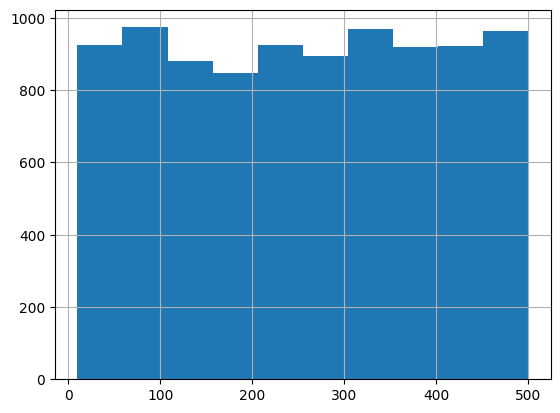

In [71]:
df.avg_order_value.hist()

In [72]:
## Se crea la variable avg_time_per_page para poder ejecutar el ejercicio 2

df["avg_time_per_page"] = df["time_on_site_minutes"] / df["pages_per_session"].replace(0, np.nan)


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10000 non-null  object 
 1   age_group                9507 non-null   object 
 2   location                 9702 non-null   object 
 3   device_type              9819 non-null   object 
 4   subscription_type        9894 non-null   object 
 5   days_since_registration  10000 non-null  int64  
 6   total_purchases          10000 non-null  int64  
 7   avg_order_value          9223 non-null   float64
 8   last_purchase_days       8526 non-null   float64
 9   sessions_last_30_days    10000 non-null  int64  
 10  time_on_site_minutes     9001 non-null   float64
 11  pages_per_session        9046 non-null   float64
 12  cart_abandonment_rate    8779 non-null   float64
 13  purchase_frequency       9200 non-null   float64
 14  dar_promocion          

## 2) Feature engineering (crear más features)

Feature engineering = crear variables nuevas a partir de variables existentes.

- Puede mejorar la señal del modelo (resumir patrones útiles).
- Riesgo: **data leakage** si una feature usa información que no estaría disponible al momento de predecir en producción.

En este caso creamos features derivadas simples (tasas / diferencias) para practicar el flujo.

### Cuidado con los valores centinela (*sentinel values*)

`last_purchase_days` usa `999` para marcar "todavía no ha comprado" (ver `generate_data.py`). Ese `999` **no es una cantidad real de días**: es una señal, no un dato.

Si restamos directamente `days_since_registration - last_purchase_days` para un usuario sin compras, el resultado es un número negativo enorme (hasta -988 en pruebas) que no significa nada y que el modelo interpretaría como una magnitud real. Por eso, la siguiente celda excluye explícitamente esos casos (los deja como valor faltante, para que el `Pipeline` los impute igual que cualquier otro dato ausente).

In [74]:
days = df['days_since_registration'].clip(lower=1)  # Evitar división por cero, dejar 1 si el valor es menor a 0

df['total_purchases_per_day'] = df['total_purchases'] / days

# 999 en 'last_purchase_days' es un valor centinela ("todavia no compro"), no una cantidad
# real de dias. Si no lo excluimos, esta resta genera outliers artificiales (hasta -988 en
# pruebas) para los usuarios sin compras. Lo dejamos como NaN para esos casos: el Pipeline
# se encarga de imputarlo mas adelante, igual que cualquier otro valor faltante.
df["days_between_first_and_last_purchase"] = np.where(
    df["total_purchases"] > 0,
    df["days_since_registration"] - df["last_purchase_days"],
    np.nan,
)

df["bucket_avg_order_value"] = pd.cut(df["avg_order_value"], bins=3, labels=["low", "medium", "high"])

## 3) Split de datos (train/test)

Separaremos los datos para simular el escenario real:

- Entrenas con `train`.
- Evalúas con `test` (datos “nuevos” para el modelo).

`random_state` asegura reproducibilidad.

`X` = features (entradas) y `y` = target (lo que quieres predecir).

In [75]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["dar_promocion"])
y = df["dar_promocion"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

## 4) Preprocesamiento: numéricas vs categóricas (y por qué)

En este dataset tienes dos familias de features:

### Variables numéricas
Ejemplos: `avg_order_value`, `time_on_site_minutes`, `purchase_frequency`.

- **Imputación**: muchos modelos no aceptan `NaN`.
- **Escalado** (por ejemplo `StandardScaler`): en modelos lineales (Logistic Regression) ayuda porque hace comparables las magnitudes.

### Variables categóricas
Ejemplos: `age_group`, `location`, `device_type`, `subscription_type`.

- Deben convertirse a números. La opción clásica es **One-Hot Encoding**.
- `handle_unknown='ignore'`: si aparece una categoría nueva en producción, el pipeline no falla.

### Por qué `ColumnTransformer`
Permite aplicar transformaciones diferentes a subconjuntos de columnas (numéricas vs categóricas) en un solo objeto reproducible.

## 5) Pipeline: preprocesamiento + modelo (evitar data leakage)

Usaremos:

- `Pipeline`: encapsula todos los pasos (imputación, escalado, one-hot, modelo).
- `ColumnTransformer`: separa numéricas/categóricas.

Punto clave: si haces imputación/one-hot *antes* del split o fuera del pipeline, podrías mezclar información del test en el entrenamiento (data leakage).

In [77]:
import time # Se importa modulo para poder realizar punto 4
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier  # Se importa modulo para poder realizar punto 4

# Define numeric and categorical columns
# Incluimos aqui las features creadas en la seccion de feature engineering
# (total_purchases_per_day, days_between_first_and_last_purchase, bucket_avg_order_value):
# crearlas y no usarlas seria trabajo perdido.
numeric_features = [
    "days_since_registration",
    "total_purchases",
    "avg_order_value",
    "last_purchase_days",
    "sessions_last_30_days",
    "time_on_site_minutes",
    "pages_per_session",
    "cart_abandonment_rate",
    "purchase_frequency",
    "total_purchases_per_day",
    "days_between_first_and_last_purchase",
    "avg_time_per_page", # Se agrega nueva variable para solución del punto 2
]

categorical_features = ["age_group", "location", "device_type", "subscription_type", "bucket_avg_order_value"]

# Create preprocessing pipelines for each data type
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")), # imputar para reemplazar valores faltantes
        ("scaler", StandardScaler()), # escalar para tener las variables en la misma escala, lo que hace es cambiar la magnitud de las variables para que puedan ser comparables
        # el modelo de regresión logística es sensible a la escala de las variables, no queremos que el modelo le de más peso a cierta variable solo porque tiene valores más grandes
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), # si hay un valor en tests que no estaba en train, lo reemplaza por Unknown
        (
            "onehot",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), # drop="first" para evitar la multicolinealidad, handle_unknown="ignore" para ignorar valores desconocidos
        ),
    ]
)

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

# Create the full pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

start = time.perf_counter()
pipeline.fit(X_train, y_train)
elapsed = time.perf_counter() - start

# Fit the pipeline
#pipeline.fit(X_train, y_train)

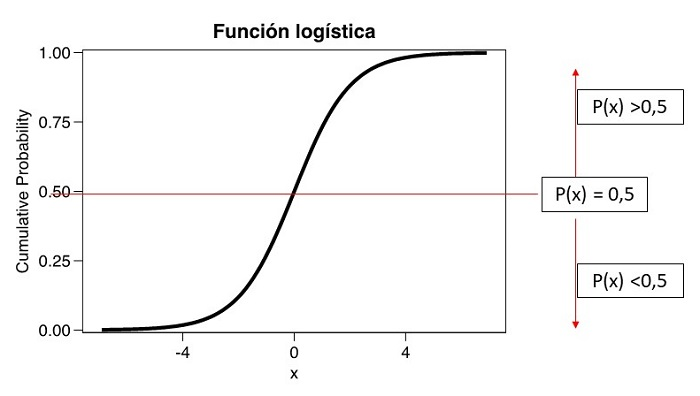

### (Opcional) Ver cuántas features quedan después del preprocesamiento

`OneHotEncoder` puede expandir bastante el número de columnas. Esto es normal. Aquí solo inspeccionamos:

- cuántas columnas finales existen
- algunos nombres generados

Esto es útil para debugging e interpretabilidad (aun si luego no interpretas coeficientes).

In [78]:
try:
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    print("Nº de features después del preprocesamiento:", len(feature_names))
    pd.Series(feature_names).head(20)
except Exception as e:
    print("No se pudieron obtener los nombres de features:", e)

Nº de features después del preprocesamiento: 33


In [79]:
feature_names

array(['num__days_since_registration', 'num__total_purchases',
       'num__avg_order_value', 'num__last_purchase_days',
       'num__sessions_last_30_days', 'num__time_on_site_minutes',
       'num__pages_per_session', 'num__cart_abandonment_rate',
       'num__purchase_frequency', 'num__total_purchases_per_day',
       'num__days_between_first_and_last_purchase',
       'num__avg_time_per_page', 'cat__age_group_26-35',
       'cat__age_group_36-45', 'cat__age_group_46-55',
       'cat__age_group_55+', 'cat__age_group_Unknown',
       'cat__location_Cordoba', 'cat__location_La Plata',
       'cat__location_Mendoza', 'cat__location_Otros',
       'cat__location_Rosario', 'cat__location_Unknown',
       'cat__device_type_Mobile', 'cat__device_type_Tablet',
       'cat__device_type_Unknown', 'cat__subscription_type_Enterprise',
       'cat__subscription_type_Free', 'cat__subscription_type_Premium',
       'cat__subscription_type_Unknown',
       'cat__bucket_avg_order_value_high',
      

In [ ]:
# Predicciones
# - y_pred: clase predicha usando el umbral por defecto (0.5)
# - y_pred_proba: probabilidad estimada de la clase positiva (y=1)

y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

In [81]:
y_pred_proba

array([0.59, 0.61, 0.52, ..., 0.57, 0.47, 0.52], shape=(2000,))

## 6) Métricas de clasificación: cómo leer el reporte

`classification_report` muestra, por clase:

- **precision**: de lo que el modelo predijo como positivo, ¿cuánto fue correcto?
- **recall**: de los positivos reales, ¿cuántos detectó?
- **f1-score**: balance entre precision y recall (útil cuando quieres un trade-off).
- **support**: cuántos ejemplos hay de cada clase.

Promedios:

- **macro avg**: promedio simple entre clases (cada clase pesa igual). Útil si quieres tratar todas las clases con la misma importancia.
- **weighted avg**: promedio ponderado por `support` (la clase más frecuente pesa más). Útil cuando el dataset está desbalanceado.

En binaria, macro vs weighted suelen ser parecidos si no hay mucho desbalance; si hay desbalance fuerte, pueden diferir bastante.

### Matriz de confusión (TP/FP/FN/TN)

La matriz de confusión te permite conectar el reporte con conteos concretos:

- **TP (True Positives)**: predijo 1 y era 1.
- **FP (False Positives)**: predijo 1 y era 0.
- **FN (False Negatives)**: predijo 0 y era 1.
- **TN (True Negatives)**: predijo 0 y era 0.

Intuición:

- Subir **precision** suele implicar bajar **recall** (y viceversa).
- En escenarios desbalanceados, `accuracy` puede verse “bien” incluso con un modelo mediocre.

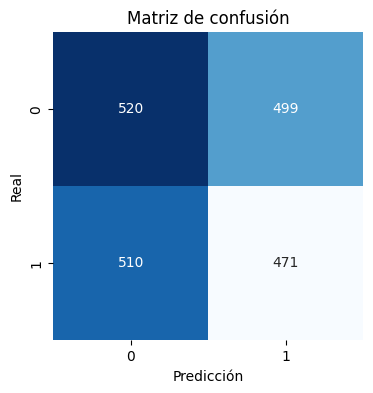

In [82]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## 7) Umbral (threshold) y trade-off precision/recall

En clasificación binaria, `predict()` usa un umbral por defecto (típicamente 0.5):

- Si `P(y=1) >= 0.5` entonces predice 1.
- Si no, predice 0.

Cambiar el umbral cambia el equilibrio:

- Umbral **más bajo** (ej. 0.3): más positivos predichos → suele subir `recall` y bajar `precision`.

¿Explicación?
- Voy a aumentar mis positivos pero realmente pocos son buenos. … tendremos más falsos positivos y pocos verdaderos positivos. 
- Aumentan los TP, pero aumentan todavía más los FP (por eso la precisión baja).

---------
- Umbral **más alto** (ej. 0.7): menos positivos predichos → suele subir `precision` y bajar `recall`.

¿Explicación?
- Si subimos el umbral, nos volvemos más estrictos y solo marcamos como positivo a los casos con probabilidad muy alta. Eso reduce los falsos positivos (FP), así que la precision sube, pero aumenta los falsos negativos (FN) (positivos reales que ya no alcanzan el umbral), por lo que el recall baja

Esto es clave en negocio:

- Si el costo de **no dar promoción a alguien que sí la necesitaba** es alto → priorizas `recall`.
- Si el costo de **dar promoción innecesaria** es alto → priorizas `precision`.

In [83]:
from sklearn.metrics import classification_report

for thr in [0.3, 0.35, 0.5, 0.7]: # Se agrega 0.35 como nuevo umbral para realizar punto 3
    y_pred_thr = (y_pred_proba >= thr).astype(int)
    print(f"\n--- Threshold = {thr} ---")
    print(classification_report(y_test, y_pred_thr))


--- Threshold = 0.3 ---
              precision    recall  f1-score   support

           0       0.50      0.00      0.01      1019
           1       0.49      1.00      0.66       981

    accuracy                           0.49      2000
   macro avg       0.50      0.50      0.33      2000
weighted avg       0.50      0.49      0.33      2000


--- Threshold = 0.35 ---
              precision    recall  f1-score   support

           0       0.58      0.02      0.03      1019
           1       0.49      0.99      0.66       981

    accuracy                           0.49      2000
   macro avg       0.54      0.50      0.35      2000
weighted avg       0.54      0.49      0.34      2000


--- Threshold = 0.5 ---
              precision    recall  f1-score   support

           0       0.50      0.46      0.48      1019
           1       0.48      0.53      0.50       981

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      200

In [84]:
# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.48677072423144757

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.50      0.51      0.51      1019
           1       0.49      0.48      0.48       981

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



In [85]:
print(f"RandomForest        -> ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f} | tiempo entrenamiento: {elapsed_rf:.3f}s")

RandomForest        -> ROC-AUC: 0.4868 | tiempo entrenamiento: 2.043s


### ¿Por qué el ROC-AUC da cerca de 0.5?

No es un error del pipeline. La columna `dar_promocion` se generó al azar (`random.choices([0, 1], ...)` en `generate_data.py`), sin relación real con ninguna feature. Un ROC-AUC cercano a 0.5 es exactamente lo esperado: el modelo no tiene ninguna señal real que aprender.

El objetivo de este notebook nunca fue lograr un buen score (ver la introducción): es practicar el flujo completo — split, `Pipeline`, `ColumnTransformer`, métricas y umbral — con datos donde no hay trampa posible.

## Ejercicios de equipo (salas de Zoom)

Formen equipos de 2-3 personas. Cada ejercicio tiene un tiempo sugerido y termina con algo concreto para compartir en la plenaria. Trabajen sobre una copia del notebook (no hace falta subir nada a este repositorio a menos que la profesora lo pida).

### Ejercicio 1 (15 min) — Otra estrategia de imputación

Cambien `SimpleImputer(strategy="median")` por `strategy="mean"` en `numeric_transformer` y vuelvan a entrenar. Comparen el `classification_report` con el original.

**Entregable:** ¿cambió algo la métrica? ¿Por qué sí o por qué no, considerando que el target es aleatorio?

### Ejercicio 2 (20 min) — Una feature nueva, de principio a fin

Creen **una** feature derivada distinta a las que ya existen (por ejemplo, `sessions_last_30_days / time_on_site_minutes`). Agréguenla en la sección de feature engineering y en `numeric_features` o `categorical_features`, según corresponda, para que el `Pipeline` la use.

**Entregable:** el nombre de la feature, una línea explicando qué representa, y si tiene o no algún riesgo de *data leakage*.

### Ejercicio 3 (15 min) — Cambiar el umbral con criterio de negocio

Retomen la celda de umbrales (0.3 / 0.5 / 0.7). Elijan un umbral distinto y justifiquen la elección con un argumento de negocio: ¿es peor no dar una promoción a quien la necesitaba, o darla de más?

**Entregable:** el umbral elegido y una frase justificando la decisión.

### Ejercicio 4 (20 min) — Cambiar de modelo

Reemplacen `LogisticRegression` por `RandomForestClassifier` (mismo `Pipeline`, mismo `preprocessor`). Comparen el ROC-AUC y el tiempo de entrenamiento aproximado.

**Entregable:** ¿el cambio de modelo mejora algo, dado que el target es aleatorio? ¿En qué tipo de problema real sí esperarían una diferencia?

## Soluciones de los ejercicios



## Ejercicio 1

Cambiar la estrategia de imputación es una decisión que en datos reales sí puede importar (por ejemplo, si hay outliers que distorsionan la media), pero en este dataset sintético con target aleatorio el efecto es prácticamente nulo porque no hay relación real que el modelo pueda capturar de todas formas.

La media y la mediana son parecidas (no hay outliers extremos que las separen mucho), así que los valores imputados terminan siendo casi los mismos.

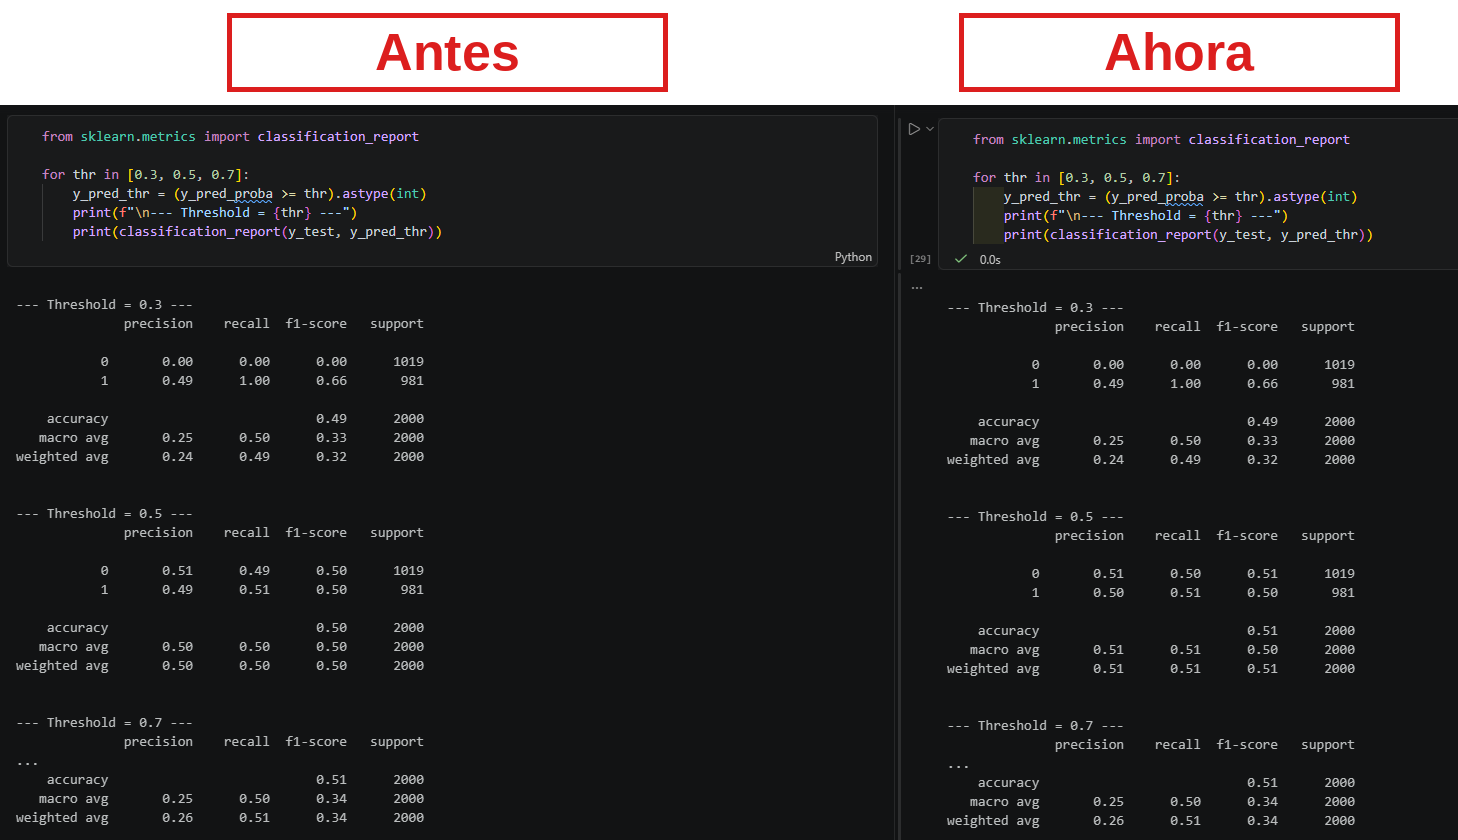

### Ejercicio 2 

**Feature:** `avg_time_per_page = time_on_site_minutes / pages_per_session`

Esta feature es el tiempo promedio (en minutos) que el usuario pasa por cada página que visita en una sesión. Es una medida de interacción donde los valores altos pueden indicar que el usuario lee con detenimiento o esta confundido; valores bajos pueden indicar navegación rápida tipo scroll.

La variable no representa riesgo de data leakage. Toda vez que es la división entre dos columnas que ya existen para ese mismo usuario en el momento de la predicción (`time_on_site_minutes` y `pages_per_session`), calculada fila a fila; ademas no usa el target ni estadísticas agregadas de otras filas a diferencia de la mediana/media, que se calculan con todo el dataset y sí causarían data leakage. Esta se calcula por separado sobre `X_train` y `X_test` (nunca mezclando ambos) para mantener la misma disciplina que el resto del pipeline. 

### Ejercicio 3 

Umbral elegido 0.35 

En este caso de uso, el costo de no darle una promoción a alguien que sí la necesitaba es más alto que el costo de darle una promoción de más a alguien que igual hubiera comprado (ese costo es solo el margen del descuento). Por eso conviene priorizar `recall` sobre `precision`; un umbral más bajo que 0.5 captura más verdaderos positivos, aunque a costa de más falsos positivos.

### Ejercicio 4

El ROC-AUC de `RandomForestClassifier` sigue estando alrededor ~0.5, el `RandomForest` tarda notablemente más en entrenar alrededore de 2.043s (entrena 100 árboles) que la regresión logística que se demora 0.035s.

En un problema real (con una relación genuina entre features y target), sí se esperaría una diferencia: `RandomForestClassifier` puede capturar relaciones no lineales e interacciones entre variables que `LogisticRegression` no modela directamente. Esto suele traducirse en mejor ROC-AUC en datasets con estructura no lineal, a cambio de más tiempo de entrenamiento/inferencia y menor interpretabilidad de los coeficientes.

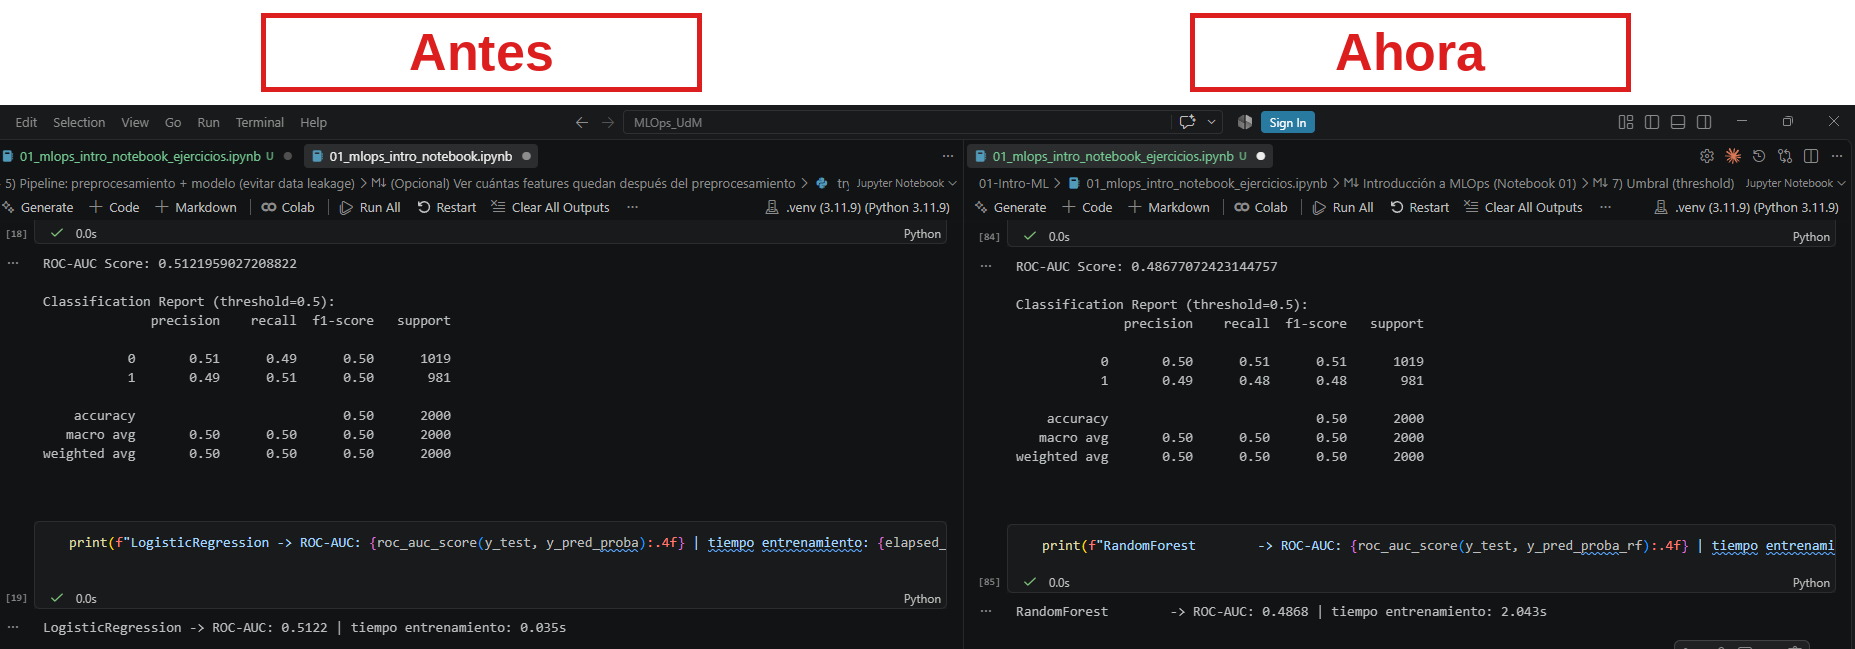